# XGBoost for time series: the case for it, and two ways to lose it

Real electricity relationships are not straight lines. The merit-order curve is convex — a
hydro shortfall of a few GW nudges price up gently, a severe one forces expensive peakers on
and price jumps. A linear model can only fit the average slope across that whole curve. A tree
ensemble fits the curve. That's the case for XGBoost over ElasticNet on this kind of data, and
we check it holds before doing anything else.

Then two ways that advantage gets lost, and what to do about each:
1. **Concurvity** — a raw feature with its own seasonal cycle gets tangled up with the calendar
   terms, and the tangle breaks when the feature's relationship to the calendar shifts.
2. **Extrapolation** — the same flexibility that lets a tree fit a curve means it cannot
   continue that curve past the edge of the data it was trained on. It flattens out exactly
   when the true relationship is accelerating.

Section A also carries a third model throughout: a **GAM** (Generalized Additive Model) —
linear terms for the calendar, a penalized spline for the feature. It's the industry baseline
this whole notebook's vocabulary comes from (`mgcv::concurvity()` is a real function), and it's
a fair third opinion on both questions: can it find the curve, and what does it do off the edge
of the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from pygam import LinearGAM, l, s

plt.rcParams["figure.figsize"] = (9, 3.6)
plt.rcParams["axes.spines.top"] = plt.rcParams["axes.spines.right"] = False
PURPLE, GREEN, AMBER, GREY = "#8172B2", "#55A868", "#DD8452", "#666666"
fourier_cols = ["sin1", "cos1", "sin2", "cos2"]

def add_calendar(df):
    for i in [1, 2]:
        df[f"sin{i}"] = np.sin(2 * np.pi * i * df["t_years"])
        df[f"cos{i}"] = np.cos(2 * np.pi * i * df["t_years"])
    df["doy"], df["year"] = df.index.dayofyear, df.index.year
    return df

def fit_enet(train_df, cols, target="price"):
    m = make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1, .5, .9, 1], cv=5, random_state=0, max_iter=10000))
    return m.fit(train_df[cols], train_df[target])

def fit_xgb(train_df, cols, target="price", **kw):
    m = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=0, **kw)
    return m.fit(train_df[cols], train_df[target])

def fit_gam(train_df, cols, target="price"):
    # linear terms for every column except the last, a penalized spline for the last (the feature)
    terms = l(0)
    for i in range(1, len(cols) - 1):
        terms += l(i)
    terms += s(len(cols) - 1, n_splines=15)
    gam = LinearGAM(terms)
    return gam.gridsearch(train_df[cols].values, train_df[target].values, progress=False)

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

## Section A — the case for XGBoost

Price = calendar-driven demand effect + a convex response to a hydro shortfall (linear on the
surplus side — surplus hydro just displaces the next cheapest plant — quadratic on the shortfall
side, since a deepening shortfall forces progressively more expensive peakers on). ElasticNet
only ever sees a straight line through this; XGBoost doesn't have to be told the shape.

ElasticNet    1.90
XGBoost       1.56
GAM           1.52
dtype: float64


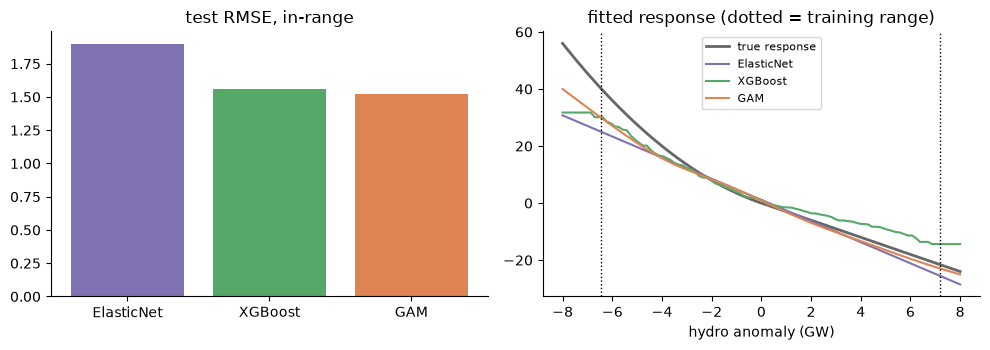

In [2]:
def simulate_market(n_years, beta1=-3.0, beta_conv=0.0, sigma_y=1.0, extra_shock=None, seed=0):
    rng = np.random.default_rng(seed)
    n_days = int(n_years * 365.25)
    dates = pd.date_range("2013-01-01", periods=n_days, freq="D")
    t = (dates - dates[0]).days / 365.25
    demand_effect = 12 * np.sin(2 * np.pi * t) + 6 * np.cos(2 * np.pi * t)
    seasonal_X = 3.0 * np.sin(2 * np.pi * (t + 0.30))

    rho, sigma_innov = 0.97, 0.5
    anomaly_X = np.empty(n_days); anomaly_X[0] = 0.0
    innov = rng.normal(0, sigma_innov, n_days)
    if extra_shock is not None:
        innov[np.searchsorted(t, extra_shock[0])] += extra_shock[1]
    for i in range(1, n_days):
        anomaly_X[i] = rho * anomaly_X[i - 1] + innov[i]

    X = 6.0 + seasonal_X + anomaly_X + rng.normal(0, 0.2, n_days)
    g = beta1 * anomaly_X + beta_conv * np.maximum(0, -anomaly_X) ** 2  # linear surplus side, convex shortfall side
    price = 70.0 + demand_effect + g + rng.normal(0, sigma_y, n_days)
    return add_calendar(pd.DataFrame({"t_years": t, "X": X, "price": price, "anomaly_X": anomaly_X}, index=dates))

train_years_A = 12
df_a = simulate_market(train_years_A + 3, beta_conv=0.5)
train_a, test_a = df_a[df_a["t_years"] < train_years_A], df_a[df_a["t_years"] >= train_years_A]
cols = fourier_cols + ["X"]
enet_a, xgb_a, gam_a = fit_enet(train_a, cols), fit_xgb(train_a, cols), fit_gam(train_a, cols)

rmse_a = {"ElasticNet": rmse(test_a["price"], enet_a.predict(test_a[cols])),
          "XGBoost": rmse(test_a["price"], xgb_a.predict(test_a[cols])),
          "GAM": rmse(test_a["price"], gam_a.predict(test_a[cols].values))}
print(pd.Series(rmse_a).round(2))

grid = pd.DataFrame({"anomaly_X": np.linspace(-8, 8, 100)})
grid["X"] = 6.0 + grid["anomaly_X"]
for c in fourier_cols:
    grid[c] = 0.0
grid["true"] = -3.0 * grid["anomaly_X"] + 0.5 * np.maximum(0, -grid["anomaly_X"]) ** 2
grid["ElasticNet"] = enet_a.predict(grid[cols]) - 70.0
grid["XGBoost"] = xgb_a.predict(grid[cols]) - 70.0
grid["GAM"] = gam_a.predict(grid[cols].values) - 70.0

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(rmse_a.keys(), rmse_a.values(), color=[PURPLE, GREEN, AMBER])
axes[0].set_title("test RMSE, in-range")
axes[1].plot(grid["anomaly_X"], grid["true"], color=GREY, lw=2, label="true response")
axes[1].plot(grid["anomaly_X"], grid["ElasticNet"], color=PURPLE, label="ElasticNet")
axes[1].plot(grid["anomaly_X"], grid["XGBoost"], color=GREEN, label="XGBoost")
axes[1].plot(grid["anomaly_X"], grid["GAM"], color=AMBER, label="GAM")
axes[1].axvline(train_a["anomaly_X"].min(), color="k", ls=":", lw=1)
axes[1].axvline(train_a["anomaly_X"].max(), color="k", ls=":", lw=1)
axes[1].set_xlabel("hydro anomaly (GW)"); axes[1].set_title("fitted response (dotted = training range)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

XGBoost and the GAM both win on RMSE and visibly track the kink; ElasticNet can only fit one
slope through the whole curve. The GAM's spline tracks it at least as well as XGBoost's steps —
and, note the region just past the dotted lines, keeps curving away from flat instead of
snapping to it. Worth the honesty: this needed real data volume (12 years) and a decently clean
signal — with noisier or shorter series the nonlinear models' edge shrinks or disappears,
because they have to estimate the curve's shape from data instead of assuming it.

## Pitfall 1 — concurvity

Same idea as before, condensed: hydro's seasonal timing drifts earlier as winters warm (no
single event, builds up over years), while the demand-side driver of price never moves. A raw
hydro feature entangles the two; its anomaly against a causally-updated climatology doesn't.
(An amplitude-widening version of the same story — e.g. heat pump adoption after a price shock —
breaks the same way; only the knob that moves differs.)

In [3]:
burn_in_years, train_years_b, test_years_b = 4, 5, 3
shift_year_b = burn_in_years + train_years_b

def simulate_snowmelt(phase_drift=0.03, seed=0):
    rng = np.random.default_rng(seed)
    n_days = int((burn_in_years + train_years_b + test_years_b) * 365.25)
    dates = pd.date_range("2013-01-01", periods=n_days, freq="D")
    t = (dates - dates[0]).days / 365.25
    demand_effect = 12 * np.sin(2 * np.pi * t) + 6 * np.cos(2 * np.pi * t)
    phase = 0.30 + phase_drift * t
    seasonal_X = 3.0 * np.sin(2 * np.pi * (t + phase))
    rho, sigma_innov = 0.97, 0.5
    anomaly_X = np.empty(n_days); anomaly_X[0] = 0.0
    innov = rng.normal(0, sigma_innov, n_days)
    for i in range(1, n_days):
        anomaly_X[i] = rho * anomaly_X[i - 1] + innov[i]
    X = 6.0 + seasonal_X + anomaly_X + rng.normal(0, 0.2, n_days)
    price = 70.0 + demand_effect - 3.0 * anomaly_X + rng.normal(0, 4.0, n_days)
    return add_calendar(pd.DataFrame({"t_years": t, "X": X, "price": price}, index=dates))

def build_anomaly_feature(df):
    df = df.copy(); df["climatology"] = np.nan
    for i, yr in enumerate(sorted(df["year"].unique())):
        if i == 0:
            continue
        hist = df[df["year"] < yr]
        clim = LinearRegression().fit(hist[fourier_cols], hist["X"])
        df.loc[df["year"] == yr, "climatology"] = clim.predict(df.loc[df["year"] == yr, fourier_cols])
    df["climatology"] = df["climatology"].bfill()
    df["X_anomaly"] = df["X"] - df["climatology"]
    return df

df_b = build_anomaly_feature(simulate_snowmelt())
train_b = df_b[(df_b["t_years"] >= burn_in_years) & (df_b["t_years"] < shift_year_b)]
test_b = df_b[df_b["t_years"] >= shift_year_b]
cols_raw, cols_anom = fourier_cols + ["X"], fourier_cols + ["X_anomaly"]
rmse_b = {
    "ElasticNet - raw": rmse(test_b["price"], fit_enet(train_b, cols_raw).predict(test_b[cols_raw])),
    "ElasticNet - anomaly": rmse(test_b["price"], fit_enet(train_b, cols_anom).predict(test_b[cols_anom])),
    "XGBoost - raw": rmse(test_b["price"], fit_xgb(train_b, cols_raw).predict(test_b[cols_raw])),
    "XGBoost - anomaly": rmse(test_b["price"], fit_xgb(train_b, cols_anom).predict(test_b[cols_anom])),
}
print(pd.Series(rmse_b).round(2))

ElasticNet - raw        5.72
ElasticNet - anomaly    5.21
XGBoost - raw           6.04
XGBoost - anomaly       5.76
dtype: float64


## Pitfall 2 — extrapolation

The same convex-response market as Section A, but the test period includes a shortfall deeper
than anything in the 12 years of training data. Both models were fit once, on the same data,
and never retrained.

In [4]:
extra_shock_t = train_years_A + 0.5
df_c = simulate_market(train_years_A + 3, beta_conv=0.5, extra_shock=(extra_shock_t, -14.0))
shock = df_c[(df_c["t_years"] >= extra_shock_t) & (df_c["t_years"] < extra_shock_t + 30 / 365.25)]
print("shock-window hydro anomaly range:", shock["anomaly_X"].min().round(1), "to", shock["anomaly_X"].max().round(1),
      " (training range was", train_a["anomaly_X"].min().round(1), "to", train_a["anomaly_X"].max().round(1), ")")

rmse_c = {"ElasticNet": rmse(shock["price"], enet_a.predict(shock[cols])),
          "XGBoost": rmse(shock["price"], xgb_a.predict(shock[cols])),
          "GAM": rmse(shock["price"], gam_a.predict(shock[cols].values))}
print(pd.Series(rmse_c).round(2))

shock-window hydro anomaly range: -15.1 to -3.8  (training range was -6.4 to 7.2 )
ElasticNet    44.41
XGBoost       62.09
GAM           24.94
dtype: float64


The model that lost Section A wins here — but not the model you'd expect if you only remembered
"linear extrapolates, trees don't." ElasticNet's straight line keeps extrapolating, off in the
wrong direction for values it's never seen but at least still moving. XGBoost's prediction is
flat past the last split in training — it cannot say a shortfall of 14 GW is worse than one of 8,
because it has never had to. The GAM's penalized spline does best of the three: it won the curve
in Section A *and* it's built to keep extending that curve, not flatten or straighten it, past
the boundary knots.

A natural guess — constrain the tree so price can only move one way as hydro anomaly falls —
doesn't fix this. Monotonic constraints stop the fitted curve from wiggling the wrong way *inside*
the training range; they say nothing about what happens past its edge.

In [5]:
mono = fit_xgb(train_a, cols, monotone_constraints=(0, 0, 0, 0, -1))
print("monotonic XGBoost, shock RMSE:", round(rmse(shock["price"], mono.predict(shock[cols])), 2), "(no better)")

monotonic XGBoost, shock RMSE: 61.95 (no better)


## Making extrapolation safe: clip, then extrapolate linearly

Clip the feature to the range XGBoost was actually trained on before it sees it, and add back a
linear correction — using ElasticNet's own slope — for whatever lies beyond the clip. XGBoost
still owns the shape inside the data it's seen; the line takes over only where nothing has been
learned.

In [6]:
x_min, x_max = train_a["X"].min(), train_a["X"].max()
enet_slope = enet_a.named_steps["elasticnetcv"].coef_[-1] / enet_a.named_steps["standardscaler"].scale_[-1]

def hybrid_predict(frame):
    excess = (frame["X"] - x_max).clip(lower=0) - (x_min - frame["X"]).clip(lower=0)
    clipped = frame.copy(); clipped["X"] = frame["X"].clip(x_min, x_max)
    return xgb_a.predict(clipped[cols]) + enet_slope * excess

rmse_safe = {"XGBoost (unsafe)": rmse(shock["price"], xgb_a.predict(shock[cols])),
             "XGBoost + linear tail": rmse(shock["price"], hybrid_predict(shock)),
             "ElasticNet": rmse_c["ElasticNet"],
             "GAM (no patch needed)": rmse_c["GAM"]}
print(pd.Series(rmse_safe).round(2))
print("in-range RMSE, unchanged by the guardrail:",
      round(rmse(test_a["price"], xgb_a.predict(test_a[cols])), 2), "->",
      round(rmse(test_a["price"], hybrid_predict(test_a)), 2))

XGBoost (unsafe)         62.09
XGBoost + linear tail    44.25
ElasticNet               44.41
GAM (no patch needed)    24.94
dtype: float64
in-range RMSE, unchanged by the guardrail: 1.56 -> 1.55


## Conclusion

XGBoost earns its place on this kind of data — real market responses are curved, and a linear
model can't fit a curve it's never told about. That advantage rests on two assumptions staying
true, and both are checkable, not hypothetical: that a raw feature's *own* relationship to the
calendar isn't quietly drifting (test with a deseasonalized version and see if it matters), and
that production data won't wander outside the range the model was trained on (test with a
synthetic shock, same as here). Guard the first with an anomaly feature and a climatology that
updates on its own. Guard the second with an explicit clip-and-extrapolate fallback — not a
monotonic constraint, which doesn't touch the problem. Neither guardrail costs anything when the
world behaves; both matter on exactly the days a forecast is actually for something.

The GAM is the reminder that these two guardrails are patches, not the only design. It matched
or beat XGBoost inside the data and beat both models outside it, without anything bolted on
after the fact — because a penalized spline's default behavior already includes "don't just
stop" past its boundary knots. It isn't a strictly better model — same as XGBoost and ElasticNet,
it's still fit once on one window and just as unaware of a coincidentally-seasonal feature unless
you hand it an anomaly instead of a raw value. But it's the industry baseline for exactly this
problem for a reason, and it's worth having in the comparison, not just XGBoost against its
simplest possible competitor.